# Cloud Free Mosaic and Geometric Median

## Import libraries

In [1]:
import os
import dask.config

from dask.distributed import Client, LocalCluster
from datacube import Datacube
from datacube.utils.masking import create_mask_value
from datacube_compute import geomedian_with_mads
from odc.geo.geom import point
from odc.stac import configure_s3_access
from urllib.parse import urlparse

## Configure the environment

In [2]:
# Configure AWS
os.environ["AWS_DEFAULT_REGION"] = "us-west-2"

if "AWS_NO_SIGN_REQUEST" in os.environ:
    del os.environ["AWS_NO_SIGN_REQUEST"]

configure_s3_access(requester_pays=True)

dc = Datacube()

## Pick a study area

In [3]:
# These coords are in the order Y then X, or Latitude then Longitude
coords = -6.11, 105.42  # Krakatoa
aoi_point = point(coords[1], coords[0], crs="EPSG:4326")
bbox = aoi_point.buffer(0.08).boundingbox

landsat_stretch = dict(vmin=7500, vmax=12000)

datetime = "2024"

# Preview the area
bbox.explore(zoom=8)

## Load data

This uses the Datacube library to handle loading of the actual data. The `dask_chunks` argument instructs the tool to use Dask
to lazy-load the data.

In [4]:
datasets = dc.find_datasets(
    product=["ls9_c2l2_sr"],
    latitude=(bbox.bottom, bbox.top),
    longitude=(bbox.left, bbox.right),
    time=datetime,
)

print(f"Found {len(datasets)} Landsat datasets")

data = dc.load(
    datasets=datasets,
    measurements=["red", "green", "blue", "nir08", "pixel_qa"],
    output_crs="EPSG:32750",
    resolution=30,
    time="2024",
    longitude=(bbox.left, bbox.right),
    latitude=(bbox.bottom, bbox.top),
    dask_chunks={"time": 1, "x": 1000, "y": 1000},
    group_by="solar_day",
    driver="rio",
)

data

Querying product Product(name='ls9_c2l2_sr', id_=1)


Found 46 Landsat datasets


<xarray.Dataset> Size: 87MB
Dimensions:      (y: 616, x: 616, time: 23)
Coordinates:
  * y            (y) float64 5kB 9.32e+06 9.32e+06 ... 9.301e+06 9.301e+06
  * x            (x) float64 5kB -7.992e+05 -7.992e+05 ... -7.808e+05 -7.807e+05
    spatial_ref  int32 4B 32750
  * time         (time) datetime64[ns] 184B 2024-01-11T03:06:32.361626 ... 20...
Data variables:
    red          (time, y, x) uint16 17MB dask.array<chunksize=(1, 616, 616), meta=np.ndarray>
    green        (time, y, x) uint16 17MB dask.array<chunksize=(1, 616, 616), meta=np.ndarray>
    blue         (time, y, x) uint16 17MB dask.array<chunksize=(1, 616, 616), meta=np.ndarray>
    nir08        (time, y, x) uint16 17MB dask.array<chunksize=(1, 616, 616), meta=np.ndarray>
    pixel_qa     (time, y, x) uint16 17MB dask.array<chunksize=(1, 616, 616), meta=np.ndarray>

In [5]:
# Create a small subset so we can test cloud masking
subset = data.isel(time=slice(0, 6))

# Load the subset into memory
subset = subset.compute()

/opt/conda/lib/python3.12/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(
/opt/conda/lib/python3.12/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


## Visualise data

This step uses `matplotlib` to view data as a static image. It takes a longer time to
run than previous steps, because it's actually loading the data to prepare the images.

The `to_array()` function is a trick used to be able to visualise the data as a
red, green, blue "true colour" image.

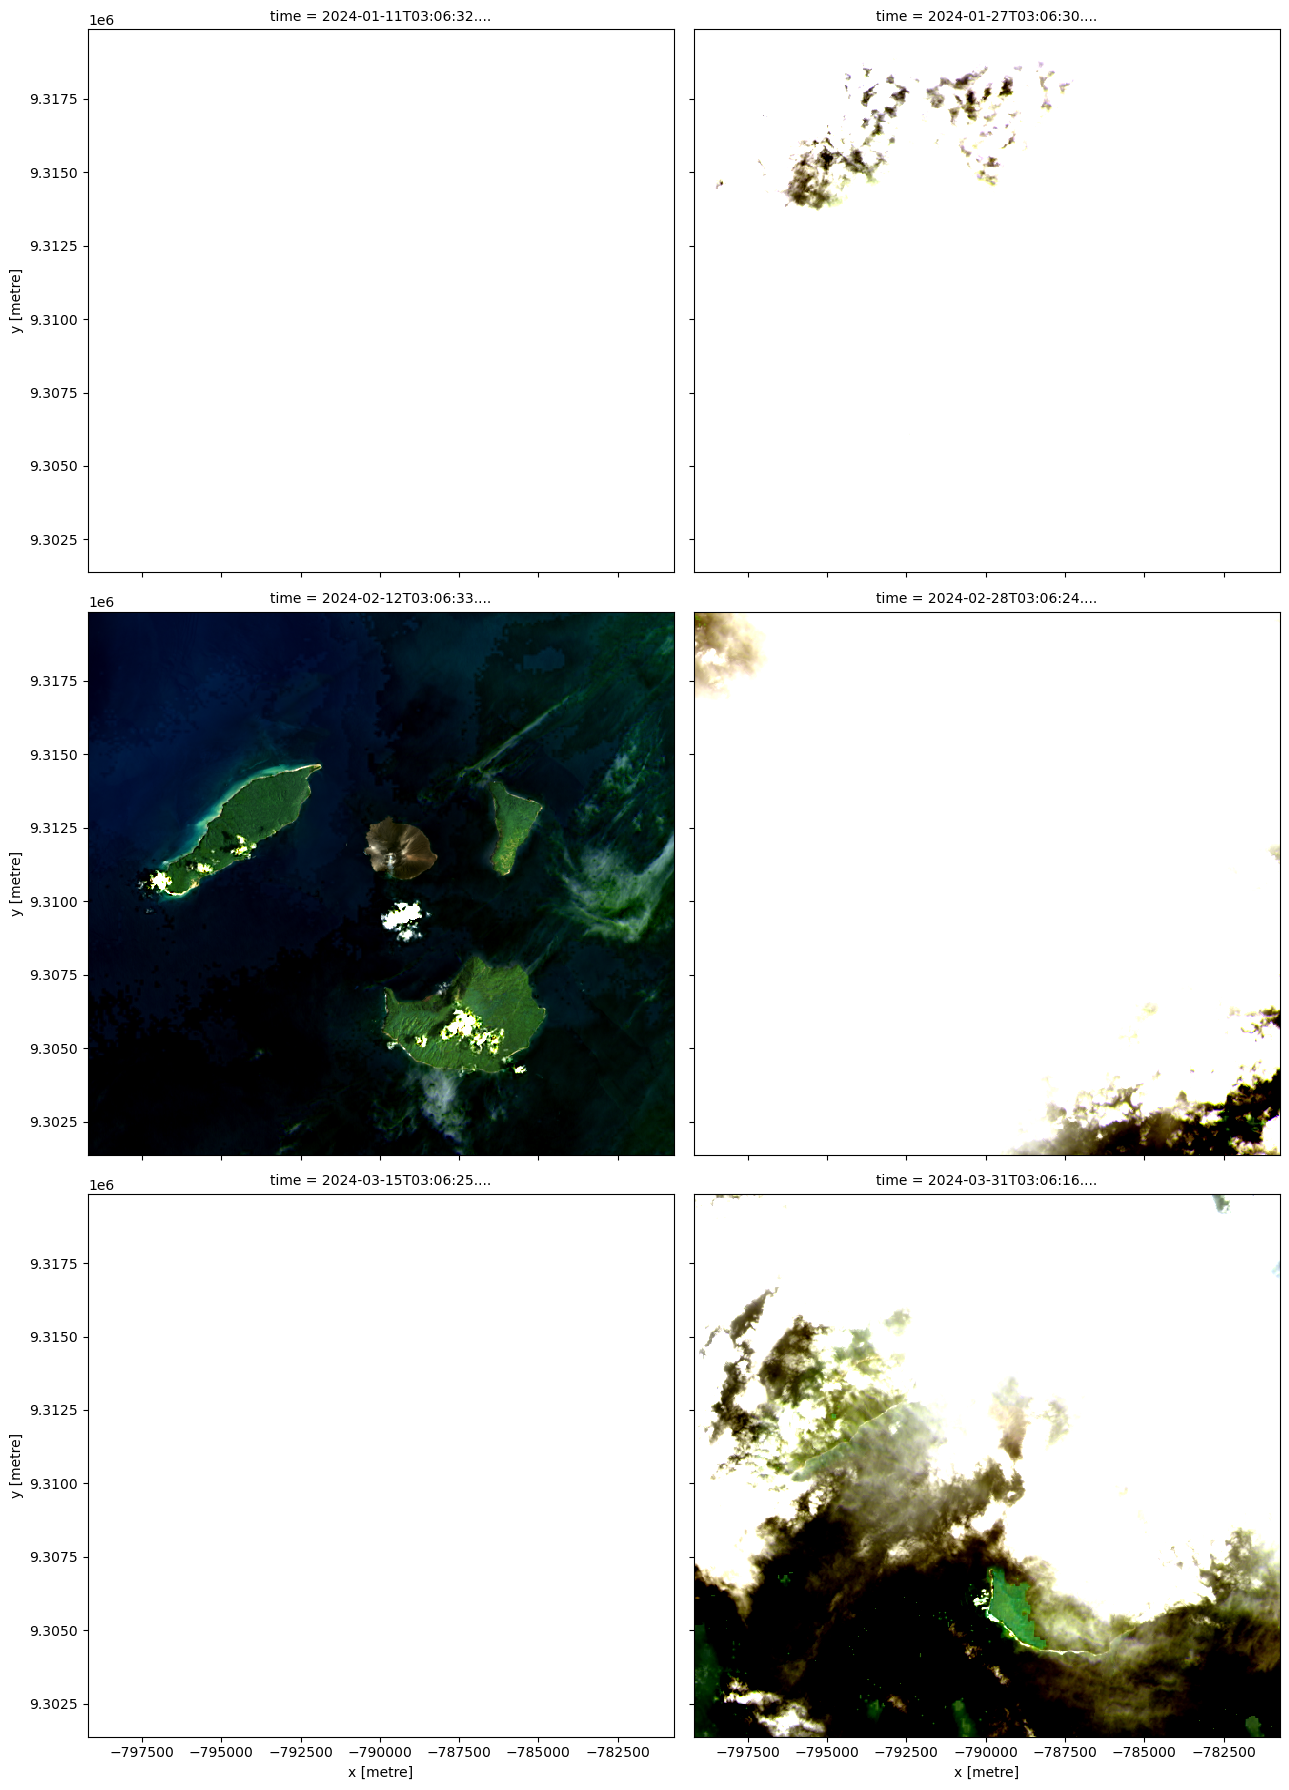

In [6]:
subset[["red", "green", "blue"]].to_array().plot.imshow(
    col="time", col_wrap=2, size=6, **landsat_stretch
)

### Cloud mask



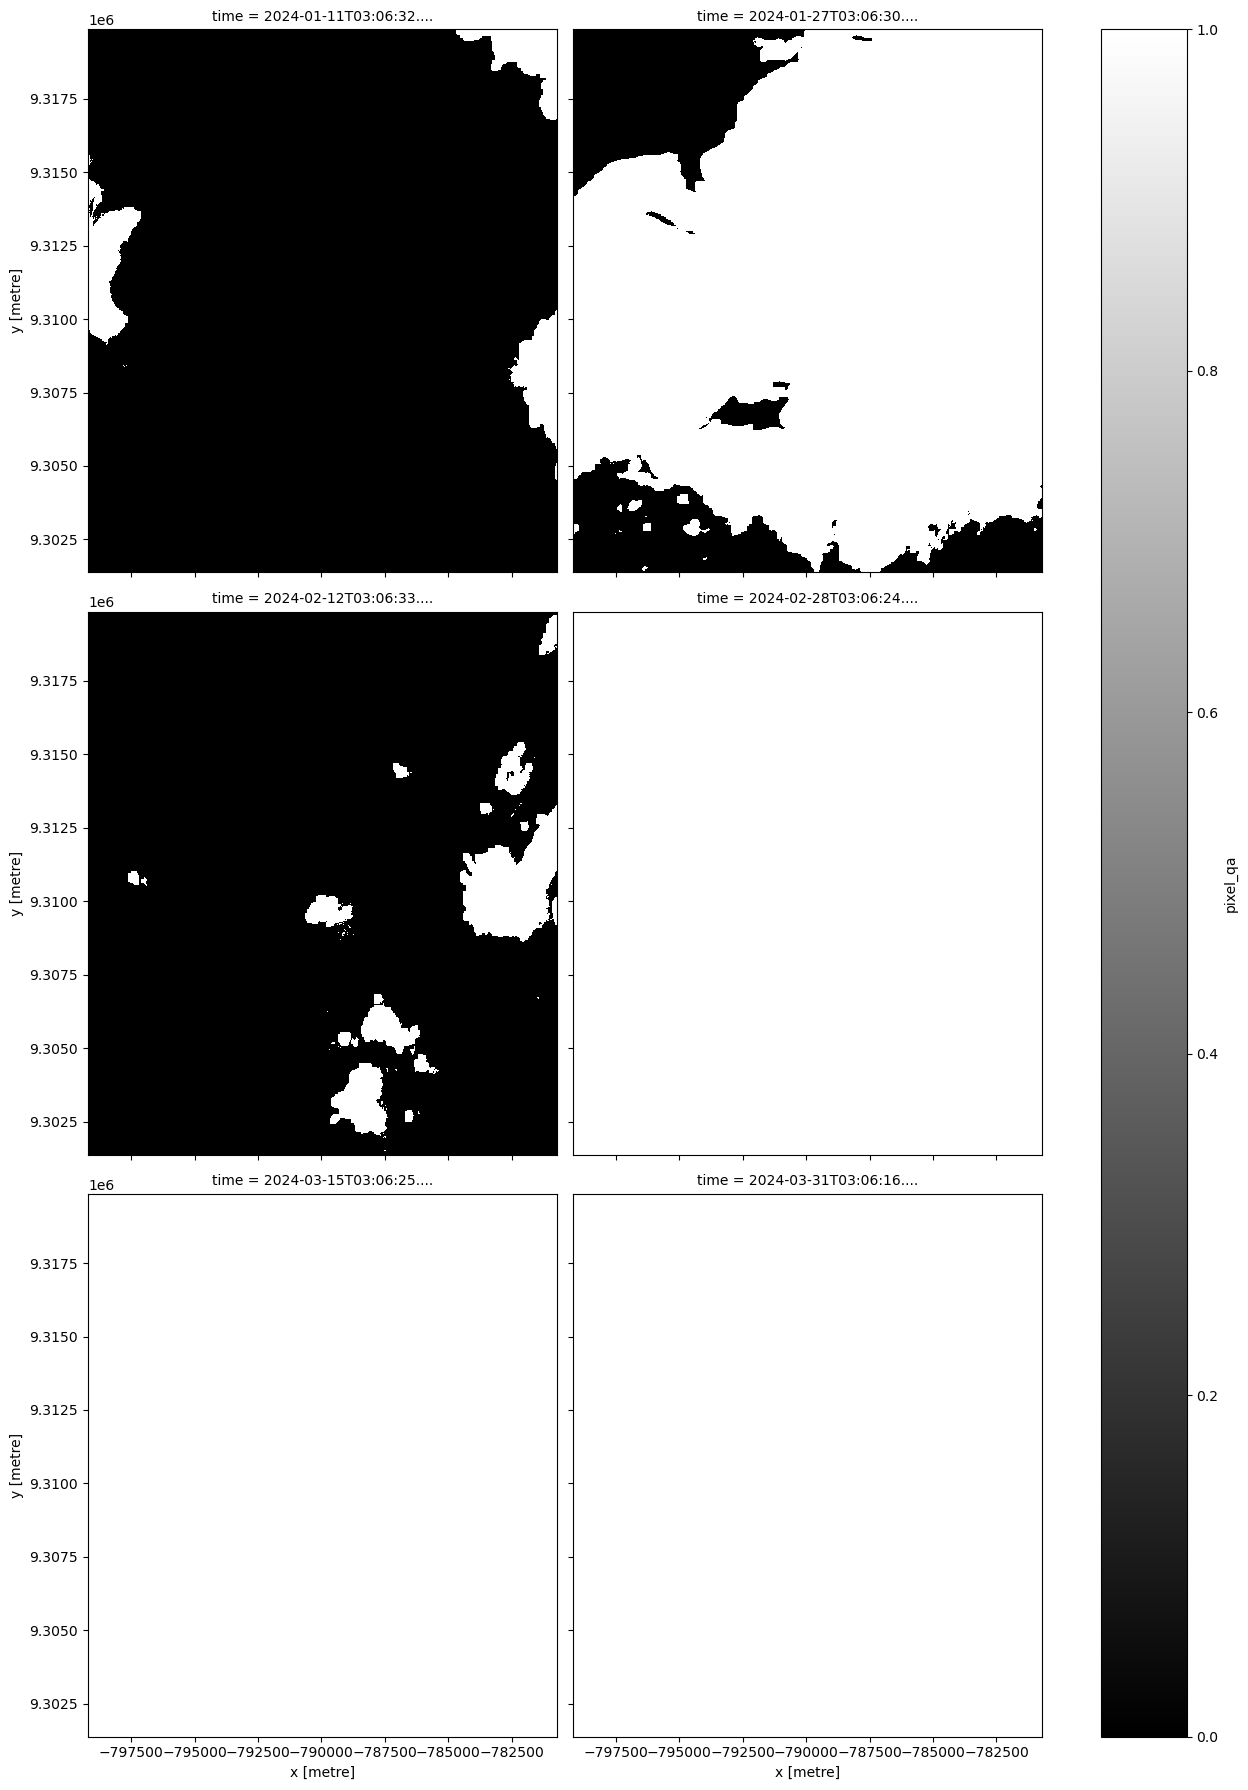

In [7]:
categories_to_mask_landsat = {
    "cloud": "high_confidence",
    "cloud_shadow": "high_confidence",
}

mask_value, _ = create_mask_value(
    datasets[0].product.measurements["qa_pixel"].flags_definition,
    **categories_to_mask_landsat,
)

mask = (subset.pixel_qa & mask_value) != 0

# Plot the result, where white is clouds or cloud shadow and black is clear
mask.plot.imshow(col="time", col_wrap=2, size=6, cmap="gray", vmin=0, vmax=1)


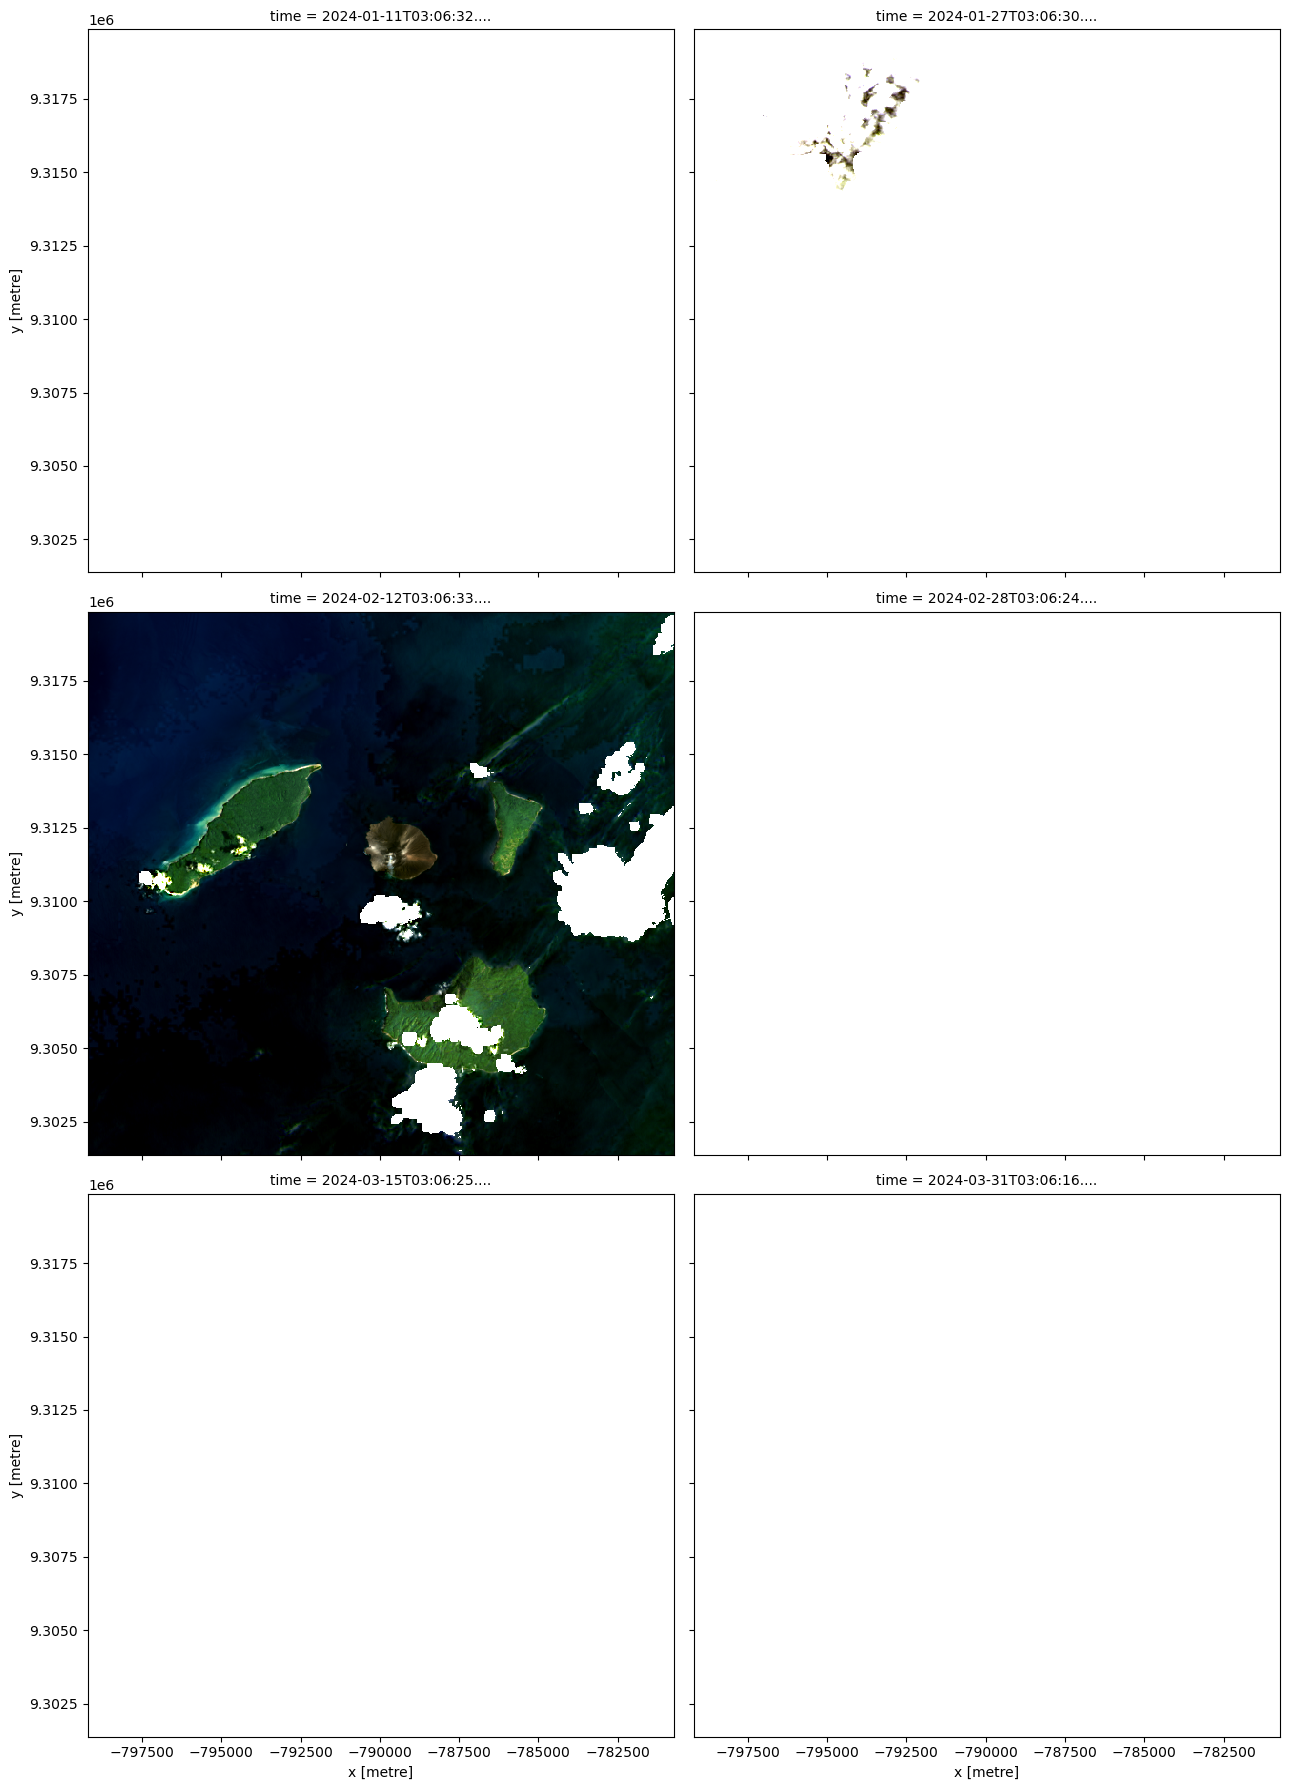

In [8]:
# Mask the subset and preview the result
masked_subset = subset.where(~mask)

masked_subset[["red", "green", "blue"]].to_array().plot.imshow(
    col="time", col_wrap=2, size=6, **landsat_stretch
)

In [9]:
# Set up a dask local cluster for parallel processing of the GeoMAD
cluster = LocalCluster(
    n_workers=2,
    threads_per_worker=2,
    memory_limit='10GB'
)

dashboard_url = cluster.dashboard_link
port = urlparse(dashboard_url).port

jupyterhub_user = os.environ.get('JUPYTERHUB_USER')
dask.config.set(**{
    "distributed.dashboard.link": f"/user/{jupyterhub_user}/proxy/{port}/status"
})

client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/rifqi.muhammad@big.go.id/proxy/8787/status,
Dashboard: /user/rifqi.muhammad@big.go.id/proxy/8787/status,Workers: 2
Total threads: 4,Total memory: 18.63 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38391,Workers: 0
Dashboard: /user/rifqi.muhammad@big.go.id/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:45287,Total threads: 2
Dashboard: /user/rifqi.muhammad@big.go.id/proxy/8787/status,Memory: 9.31 GiB
Nanny: tcp://127.0.0.1:34919,


In [10]:
# Apply the same process to the whole time series
mask = (data.pixel_qa & mask_value) != 0
masked_data = data.drop_vars("pixel_qa").where(~mask)

# Calculate the geomedian and MADs
# Note, scale and offset values are specific to Landsat 9 C2 L2 SR data
# See: https://www.usgs.gov/faqs/how-do-i-use-a-scale-factor-landsat-level-2-science-products
geomad = geomedian_with_mads(
    masked_data, scale=0.0000275, offset=-0.2, work_chunks=[1000, 1000]
).compute()

geomad

/opt/conda/lib/python3.12/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


<xarray.Dataset> Size: 11MB
Dimensions:  (y: 616, x: 616)
Coordinates:
  * y        (y) float64 5kB 9.32e+06 9.32e+06 9.32e+06 ... 9.301e+06 9.301e+06
  * x        (x) float64 5kB -7.992e+05 -7.992e+05 ... -7.808e+05 -7.807e+05
Data variables:
    smad     (y, x) float32 2MB 0.0006315 0.000702 ... 0.000447 0.000453
    nir08    (y, x) float32 2MB 7.163e+03 7.153e+03 ... 7.271e+03 7.261e+03
    green    (y, x) float32 2MB 8.358e+03 8.353e+03 ... 8.038e+03 8.037e+03
    blue     (y, x) float32 2MB 8.381e+03 8.388e+03 ... 7.982e+03 7.973e+03
    emad     (y, x) float32 2MB 891.6 898.2 894.3 914.6 ... 523.0 533.9 543.9
    count    (y, x) uint16 759kB 23 23 23 23 23 23 23 ... 23 23 23 23 23 23 23
    bcmad    (y, x) float32 2MB 0.02078 0.02131 0.022 ... 0.01496 0.01475
    red      (y, x) float32 2MB 7.242e+03 7.222e+03 ... 7.226e+03 7.215e+03

In [16]:
top = geomad.nir08 - geomad.red
bottom = geomad.nir08 + geomad.red

ndvi = top / bottom
ndvi.odc.explore(robust=True, cmap="RdYlGn")

In [17]:
top = - geomad.green - geomad.nir08 
bottom = geomad.green + geomad.nir08

ndwi = top / bottom
ndwi.odc.explore(robust=True, cmap="RdYlGn")

In [11]:
# Visualise the results
geomad.odc.explore(**landsat_stretch)

In [12]:
# Visualise the variance (MADs)
geomad.odc.explore(bands=["smad", "emad", "bcmad"], robust=True)

In [13]:
# # Clean up (close the dask client)
client.close()